# Project: Duplicate Question Detection Using NLP & Machine Learning

This notebook contains the complete end-to-end implementation of a **Duplicate Question Detection System** using Natural Language Processing (NLP) and traditional Machine Learning techniques.

The objective of this project is to determine whether two questions have the same or highly similar meaning. The system processes a pair of questions, extracts meaningful textual features, and uses a Machine Learning classifier to predict whether the questions are duplicate or non-duplicate.

### Project Objective:
Build a binary classification model that predicts:

- **1 → Duplicate Questions**
- **0 → Non-Duplicate Questions**

### Technologies Used:
- Python
- Pandas
- NumPy
- NLTK / Regular Expressions
- Scikit-learn
- Matplotlib
- Seaborn
- TF-IDF
- Cosine Similarity
- Logistic Regression
- Streamlit

### Pipeline Phases:
1. **Data Ingestion & Dataset Understanding:** Load the Quora dataset and inspect its structure, columns, data types, and target distribution.
2. **Exploratory Data Analysis:** Analyze question lengths, word counts, duplicate distribution, and data quality.
3. **Text Preprocessing:** Clean and normalize the question text for NLP processing.
4. **Feature Engineering:** Extract textual similarity and question-level features.
5. **TF-IDF Vectorization:** Convert textual questions into numerical representations using TF-IDF.
6. **Similarity Analysis:** Calculate cosine similarity between question pairs.
7. **Machine Learning Modeling:** Train classification models to detect duplicate questions.
8. **Model Evaluation:** Evaluate models using accuracy, precision, recall, F1-score, and confusion matrix.
9. **Model Selection & Saving:** Select the best-performing model and save it for future predictions.
10. **Prediction System:** Build a function that predicts whether two new questions are duplicates.
11. **Streamlit Deployment:** Develop an interactive web application for real-time duplicate question detection.

### 1.1 Import Required Libraries

We begin by importing the basic Python libraries required for data loading, manipulation, and numerical analysis.

- **Pandas** is used for data manipulation and analysis.
- **NumPy** is used for numerical operations.

In [5]:
import pandas as pd
import numpy as np

### 1.2 Load the Dataset

The Quora Duplicate Questions dataset is loaded into a Pandas DataFrame.

A DataFrame provides a tabular structure that allows us to efficiently inspect, clean, transform, and analyze the dataset.

In [6]:
# Load the dataset
df = pd.read_csv("quora_duplicate_questions.csv")

# Display the first 5 rows
df.head()

,index,id,qid1,qid2,question1,question2,is_duplicate
0,0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,6,13,14,Should I buy tiago?,What keeps childern active and far from phone ...,0
4,4,7,15,16,How can I be a good geologist?,What should I do to be a great geologist?,1


### 1.3 Dataset Dimensions

We check the dimensions of the dataset to determine how many question pairs and features are available.



In [7]:
df.shape

(345036, 7)

### 1.4 Dataset Columns

We inspect the column names to understand what information is available in the dataset.



In [8]:
df.columns

Index(['index', 'id', 'qid1', 'qid2', 'question1', 'question2',
       'is_duplicate'],
      dtype='str')

### 1.5 Dataset Information

The `info()` method provides information about the DataFrame.

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 345036 entries, 0 to 345035
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   index         345036 non-null  int64
 1   id            345036 non-null  int64
 2   qid1          345036 non-null  int64
 3   qid2          345036 non-null  int64
 4   question1     345035 non-null  str  
 5   question2     345034 non-null  str  
 6   is_duplicate  345036 non-null  int64
dtypes: int64(5), str(2)
memory usage: 54.6 MB


### 1.6 Statistical Summary

We use the `describe()` method to obtain basic statistical information about the numerical columns.

This provides information such as:

- Count
- Mean
- Standard deviation
- Minimum
- Maximum
- Quartiles

The summary helps us understand the numerical characteristics of the dataset before further analysis.

In [10]:
df.describe()

,index,id,qid1,qid2,is_duplicate
count,345036.000000,345036.000000,345036.000000,345036.000000,345036.000000
mean,172517.500000,202167.901978,391861.413351,390032.565332,0.394973
std,99603.458078,116719.472849,228406.445188,228827.555423,0.488846
min,0.000000,0.000000,1.000000,2.000000,0.000000
25%,86258.750000,101066.000000,193340.500000,190723.500000,0.000000
50%,172517.500000,202134.500000,390546.000000,388065.000000,0.000000
75%,258776.250000,303269.250000,589615.250000,587984.500000,1.000000
max,345035.000000,404350.000000,789800.000000,789801.000000,1.000000


### 1.7 Missing Value Analysis

In [11]:
df.isnull().sum()

index           0
id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

### 1.8 Duplicate Row Analysis

We check whether the dataset contains completely duplicated rows.

In [12]:
df.duplicated().sum()

np.int64(0)

### 1.9 Target Variable Distribution

The target variable `is_duplicate` indicates whether the two questions in a pair have the same meaning.

- `0` → Questions are not duplicates.
- `1` → Questions are duplicates.

In [13]:
df["is_duplicate"].value_counts()

is_duplicate
0    208756
1    136280
Name: count, dtype: int64

In [14]:
df["is_duplicate"].value_counts(normalize=True) * 100

is_duplicate
0    60.502672
1    39.497328
Name: proportion, dtype: float64

### 1.10 Duplicate Question Examples

We display examples where `is_duplicate = 1`.

This allows us to understand what the model is expected to learn.

Duplicate questions may use different words or sentence structures while expressing essentially the same meaning.

In [15]:
df[df["is_duplicate"] == 1][
    ["question1", "question2", "is_duplicate"]
].head(10)

,question1,question2,is_duplicate
4,How can I be a good geologist?,What should I do to be a great geologist?,1
8,How do I read and find my YouTube comments?,How can I see all my Youtube comments?,1
9,What can make Physics easy to learn?,How can you make physics easy to learn?,1
10,What was your first sexual experience like?,What was your first sexual experience?,1
11,What would a Trump presidency mean for current...,How will a Trump presidency affect the student...,1
12,What does manipulation mean?,What does manipulation means?,1
14,Why are so many Quora users posting questions ...,Why do people ask Quora questions which can be...,1
16,Why do rockets look white?,Why are rockets and boosters painted white?,1
25,How should I prepare for CA final law?,How one should know that he/she completely pre...,1
27,What are some special cares for someone with a...,How can I keep my nose from getting stuffy at ...,1


### 1.11 Non-Duplicate Question Examples

We now examine examples where `is_duplicate = 0`.

These examples represent question pairs with different meanings.

The Machine Learning model will ultimately learn to distinguish these pairs from duplicate questions.

In [16]:
df[df["is_duplicate"] == 0][
    ["question1", "question2", "is_duplicate"]
].head(10)

,question1,question2,is_duplicate
0,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,Should I buy tiago?,What keeps childern active and far from phone ...,0
5,When do you use シ instead of し?,"When do you use ""&"" instead of ""and""?",0
6,Motorola (company): Can I hack my Charter Moto...,How do I hack Motorola DCX3400 for free internet?,0
7,Method to find separation of slits using fresn...,What are some of the things technicians can te...,0
13,Why do girls want to be friends with the guy t...,How do guys feel after rejecting a girl?,0
15,Which is the best digital marketing institutio...,Which is the best digital marketing institute ...,0
17,What's causing someone to be jealous?,What can I do to avoid being jealous of someone?,0


### 1.12 Dataset Summary

We create a compact summary of the most important characteristics of the dataset.



In [17]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["is_duplicate"].value_counts())

print("\nTarget percentage:")
print(df["is_duplicate"].value_counts(normalize=True) * 100)

Number of rows: 345036
Number of columns: 7

Columns:
['index', 'id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate']

Missing values:
index           0
id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

Target distribution:
is_duplicate
0    208756
1    136280
Name: count, dtype: int64

Target percentage:
is_duplicate
0    60.502672
1    39.497328
Name: proportion, dtype: float64


## Phase 2: Exploratory Data Analysis (EDA)

In this phase, we perform Exploratory Data Analysis to understand the characteristics and patterns present in the Quora question-pair dataset.

The analysis focuses on:

- Distribution of duplicate and non-duplicate question pairs.
- Missing values and data quality.
- Question length in characters.
- Question length in words.
- Comparison of question lengths between duplicate and non-duplicate pairs.
- Identification of repeated questions.
- Understanding patterns that may be useful for feature engineering.

EDA helps us understand the dataset before applying text preprocessing and Machine Learning algorithms.

### 2.1 Duplicate vs Non-Duplicate Question Distribution
We visualize the distribution of both classes to understand the class balance in the dataset.


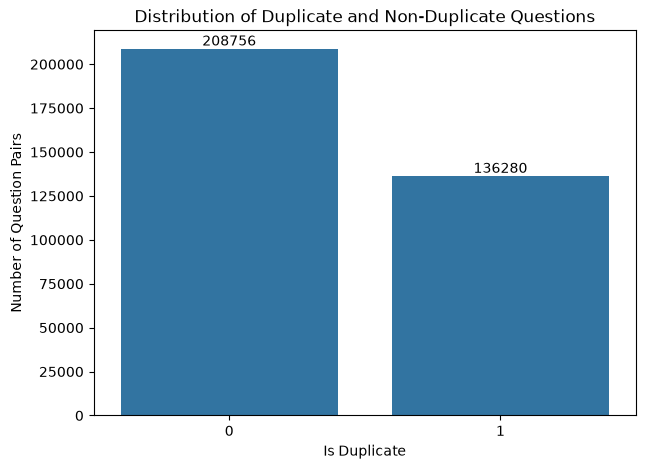

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="is_duplicate"
)

plt.title("Distribution of Duplicate and Non-Duplicate Questions")
plt.xlabel("Is Duplicate")
plt.ylabel("Number of Question Pairs")

# Add count labels on bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

### 2.2 Target Class Percentage Distribution

To better understand the class imbalance, we visualize the percentage of duplicate and non-duplicate question pairs.

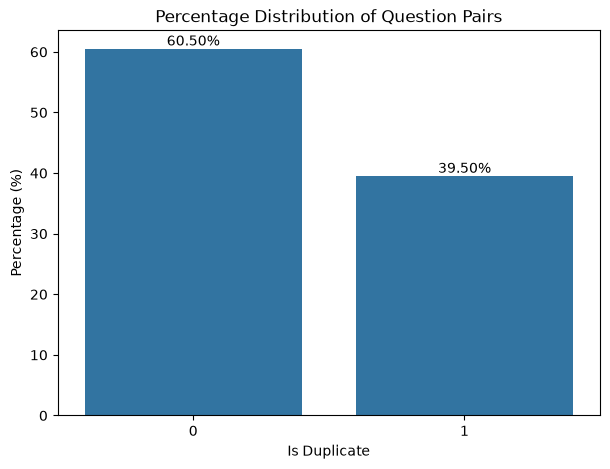

In [19]:
target_percentage = (
    df["is_duplicate"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=target_percentage.index,
    y=target_percentage.values
)

plt.title("Percentage Distribution of Question Pairs")
plt.xlabel("Is Duplicate")
plt.ylabel("Percentage (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%"
    )

plt.show()

### 2.3 Question Length Analysis

Question length can provide useful information about the structure of the question pairs.

These features will initially be used for exploratory analysis and may later be incorporated into the feature engineering stage.

In [20]:
# Handle missing values temporarily for length calculation
df["question1_clean_temp"] = df["question1"].fillna("")
df["question2_clean_temp"] = df["question2"].fillna("")

# Character count
df["q1_char_length"] = df["question1_clean_temp"].str.len()
df["q2_char_length"] = df["question2_clean_temp"].str.len()

# Word count
df["q1_word_count"] = (
    df["question1_clean_temp"]
    .str.split()
    .str.len()
)

df["q2_word_count"] = (
    df["question2_clean_temp"]
    .str.split()
    .str.len()
)

df[
    [
        "question1",
        "question2",
        "q1_char_length",
        "q2_char_length",
        "q1_word_count",
        "q2_word_count"
    ]
].head()

,question1,question2,q1_char_length,q2_char_length,q1_word_count,q2_word_count
0,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,66,57,14,12
1,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,51,88,8,13
2,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,73,59,14,10
3,Should I buy tiago?,What keeps childern active and far from phone ...,19,62,4,11
4,How can I be a good geologist?,What should I do to be a great geologist?,30,41,7,9


### 2.4 Statistical Summary of Question Length

We examine descriptive statistics for character length and word count.

In [21]:
df[
    [
        "q1_char_length",
        "q2_char_length",
        "q1_word_count",
        "q2_word_count"
    ]
].describe()

,q1_char_length,q2_char_length,q1_word_count,q2_word_count
count,345036.000000,345036.000000,345036.000000,345036.000000
mean,54.905413,54.817231,10.116278,10.211048
std,25.317876,27.068664,4.558836,4.970048
min,0.000000,0.000000,0.000000,0.000000
25%,38.000000,37.000000,7.000000,7.000000
50%,49.000000,48.000000,9.000000,9.000000
75%,65.000000,65.000000,12.000000,12.000000
max,623.000000,1169.000000,125.000000,228.000000


### 2.5 Distribution of Question Character Length

The following visualization shows the distribution of character lengths for the two questions in each pair.

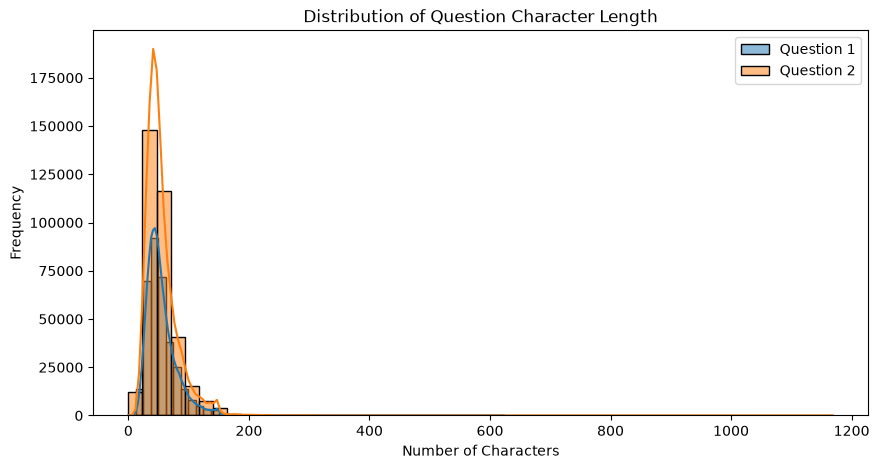

In [22]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["q1_char_length"],
    bins=50,
    kde=True,
    label="Question 1",
    alpha=0.5
)

sns.histplot(
    df["q2_char_length"],
    bins=50,
    kde=True,
    label="Question 2",
    alpha=0.5
)

plt.title("Distribution of Question Character Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.legend()

plt.show()

### 2.6 Distribution of Question Word Count

We analyze the number of words present in each question.

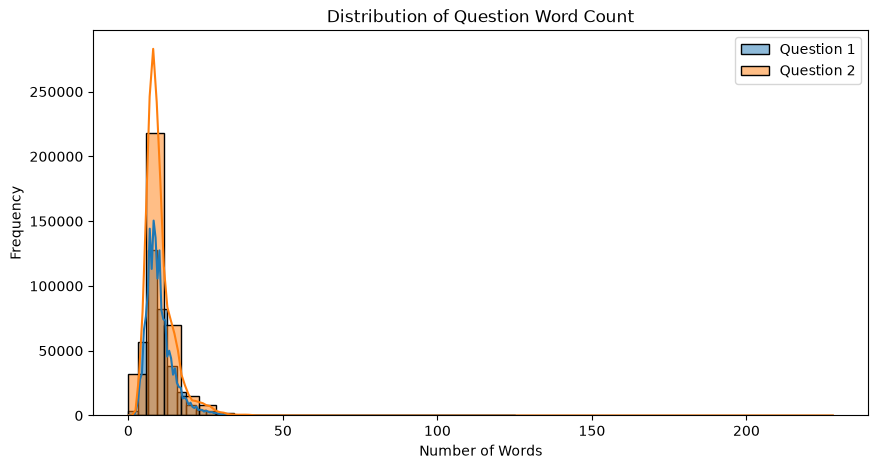

In [23]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["q1_word_count"],
    bins=40,
    kde=True,
    label="Question 1",
    alpha=0.5
)

sns.histplot(
    df["q2_word_count"],
    bins=40,
    kde=True,
    label="Question 2",
    alpha=0.5
)

plt.title("Distribution of Question Word Count")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.legend()

plt.show()

### 2.7 Question Length Comparison by Duplicate Status

We compare the question lengths for duplicate and non-duplicate pairs.

This analysis helps determine whether length-based features could contribute to the Machine Learning model.

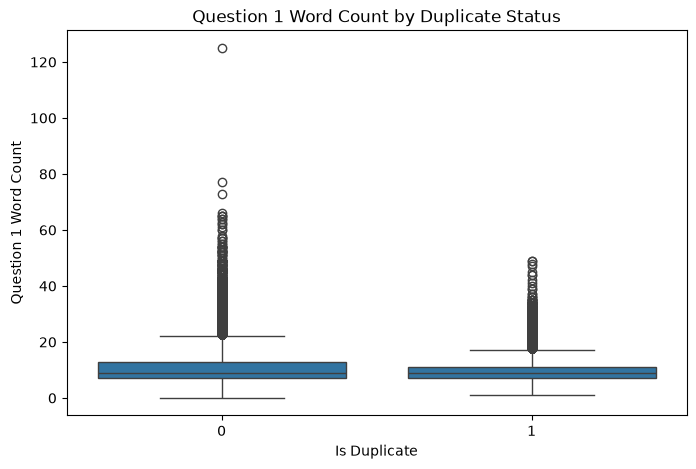

In [24]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="is_duplicate",
    y="q1_word_count"
)

plt.title("Question 1 Word Count by Duplicate Status")
plt.xlabel("Is Duplicate")
plt.ylabel("Question 1 Word Count")

plt.show()

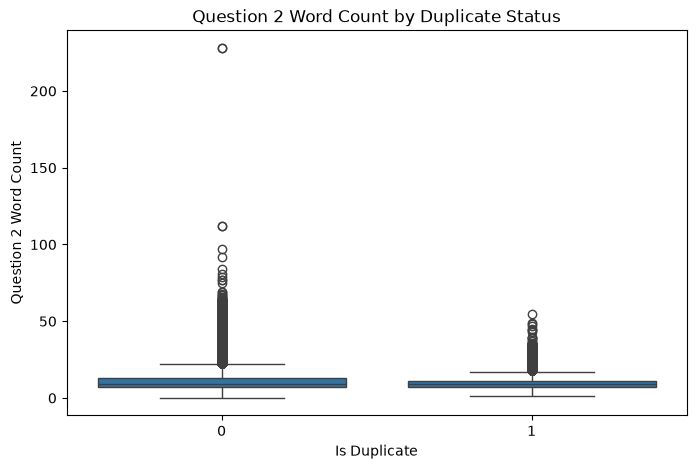

In [25]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="is_duplicate",
    y="q2_word_count"
)

plt.title("Question 2 Word Count by Duplicate Status")
plt.xlabel("Is Duplicate")
plt.ylabel("Question 2 Word Count")

plt.show()

### 2.8 Repeated Question Analysis

The same question may appear in multiple question pairs.
    
We examine the frequency of repeated questions to understand the structure of the dataset and identify potential data leakage considerations during model development.

In [26]:
question_counts = pd.concat([
    df["question1"].dropna(),
    df["question2"].dropna()
]).value_counts()

question_counts.head(10)

What are the best ways to lose weight?                                                                151
How can I lose weight quickly?                                                                        107
How can you look at someone's private Instagram account without following them?                       105
What's the easiest way to make money online?                                                           88
What are some things new employees should know going into their first day at AT&T?                     77
Can you see who views your Instagram?                                                                  75
What do you think of the decision by the Indian Government to demonetize 500 and 1000 rupee notes?     66
Which is the best digital marketing course?                                                            65
How can you increase your height?                                                                      61
How do l see who viewed my videos on Instagram

### 2.9 Frequently Repeated Questions

We display the most frequently occurring questions in the dataset.

Repeated questions are common in the Quora Question Pairs dataset because a single question can be paired with multiple other questions.

This observation is important when designing the train-test splitting strategy to minimize information leakage.

In [27]:
question_counts.head(10).to_frame(
    name="frequency"
)

,frequency
What are the best ways to lose weight?,151
How can I lose weight quickly?,107
How can you look at someone's private Instagram account without following them?,105
What's the easiest way to make money online?,88
What are some things new employees should know going into their first day at AT&T?,77
Can you see who views your Instagram?,75
What do you think of the decision by the Indian Government to demonetize 500 and 1000 rupee notes?,66
Which is the best digital marketing course?,65
How can you increase your height?,61
How do l see who viewed my videos on Instagram?,56


In [28]:
df.describe()

,index,id,qid1,qid2,is_duplicate,q1_char_length,q2_char_length,q1_word_count,q2_word_count
count,345036.000000,345036.000000,345036.000000,345036.000000,345036.000000,345036.000000,345036.000000,345036.000000,345036.000000
mean,172517.500000,202167.901978,391861.413351,390032.565332,0.394973,54.905413,54.817231,10.116278,10.211048
std,99603.458078,116719.472849,228406.445188,228827.555423,0.488846,25.317876,27.068664,4.558836,4.970048
min,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,86258.750000,101066.000000,193340.500000,190723.500000,0.000000,38.000000,37.000000,7.000000,7.000000
50%,172517.500000,202134.500000,390546.000000,388065.000000,0.000000,49.000000,48.000000,9.000000,9.000000
75%,258776.250000,303269.250000,589615.250000,587984.500000,1.000000,65.000000,65.000000,12.000000,12.000000
max,345035.000000,404350.000000,789800.000000,789801.000000,1.000000,623.000000,1169.000000,125.000000,228.000000


In [29]:
# Remove temporary EDA columns
df.drop(
    columns=["question1_clean_temp", "question2_clean_temp"],
    inplace=True,
    errors="ignore"
)

## Phase 3: Text Preprocessing

Raw question text contains variations that are not necessarily useful for Machine Learning, such as differences in capitalization, punctuation, extra spaces, and inconsistent textual formatting.

In this phase, we clean and normalize the question text before extracting Machine Learning features.

### Preprocessing Operations:

1. Handle missing question values.
2. Convert text to lowercase.
3. Remove unnecessary punctuation and special characters.
4. Normalize whitespace.
5. Preserve meaningful words and question structure.
6. Create cleaned versions of `question1` and `question2`.

The purpose of preprocessing is to reduce irrelevant textual variation while preserving information that can help determine whether two questions have the same meaning.

We avoid aggressive preprocessing such as removing all stopwords because words such as "how", "why", "can", "does", and "is" can be important for distinguishing the meaning of questions.

### 3.1 Handling Missing Questions

In [30]:
print("Missing question1:", df["question1"].isnull().sum())
print("Missing question2:", df["question2"].isnull().sum())

Missing question1: 1
Missing question2: 2


In [31]:
df = df.dropna(
    subset=["question1", "question2"]
).copy()

print("Dataset shape after removing missing questions:")
print(df.shape)

print("\nMissing values after cleaning:")
print(df[["question1", "question2"]].isnull().sum())

Dataset shape after removing missing questions:
(345033, 11)

Missing values after cleaning:
question1    0
question2    0
dtype: int64


### 3.2 Text Cleaning Function

A reusable text-cleaning function is created to apply the same preprocessing steps consistently to both questions.

The function:

- Converts text to lowercase.
- Removes punctuation and unnecessary special characters.
- Replaces multiple spaces with a single space.
- Removes leading and trailing whitespace.

Using the same function for both questions ensures that the preprocessing pipeline remains consistent during both training and prediction.

In [32]:
import re

def clean_text(text):
    """
    Clean and normalize question text.
    """
    
    # Convert text to lowercase
    text = text.lower()
    
    # Remove punctuation and special characters
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

### 3.3 Apply Text Cleaning to Question Pairs

The cleaning function is now applied to both `question1` and `question2`.

The original columns are retained so that we can compare the original and cleaned text during analysis.

In [33]:
df["question1_clean"] = df["question1"].apply(clean_text)
df["question2_clean"] = df["question2"].apply(clean_text)

df[
    [
        "question1",
        "question1_clean",
        "question2",
        "question2_clean",
        "is_duplicate"
    ]
].head(10)

,question1,question1_clean,question2,question2_clean,is_duplicate
0,What is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0
1,What is the story of Kohinoor (Koh-i-Noor) Dia...,what is the story of kohinoor koh i noor diamond,What would happen if the Indian government sto...,what would happen if the indian government sto...,0
2,How can I increase the speed of my internet co...,how can i increase the speed of my internet co...,How can Internet speed be increased by hacking...,how can internet speed be increased by hacking...,0
3,Should I buy tiago?,should i buy tiago,What keeps childern active and far from phone ...,what keeps childern active and far from phone ...,0
4,How can I be a good geologist?,how can i be a good geologist,What should I do to be a great geologist?,what should i do to be a great geologist,1
5,When do you use シ instead of し?,when do you use instead of,"When do you use ""&"" instead of ""and""?",when do you use instead of and,0
6,Motorola (company): Can I hack my Charter Moto...,motorola company can i hack my charter motorol...,How do I hack Motorola DCX3400 for free internet?,how do i hack motorola dcx3400 for free internet,0
7,Method to find separation of slits using fresn...,method to find separation of slits using fresn...,What are some of the things technicians can te...,what are some of the things technicians can te...,0
8,How do I read and find my YouTube comments?,how do i read and find my youtube comments,How can I see all my Youtube comments?,how can i see all my youtube comments,1
9,What can make Physics easy to learn?,what can make physics easy to learn,How can you make physics easy to learn?,how can you make physics easy to learn,1


### 3.4 Check for Empty Text After Preprocessing

After removing punctuation and special characters, we verify whether any questions have become empty strings.

An empty question would not provide meaningful information to the Machine Learning model and therefore needs to be identified before feature extraction.

In [34]:
empty_q1 = (df["question1_clean"].str.strip() == "").sum()
empty_q2 = (df["question2_clean"].str.strip() == "").sum()

print("Empty cleaned Question 1:", empty_q1)
print("Empty cleaned Question 2:", empty_q2)

Empty cleaned Question 1: 10
Empty cleaned Question 2: 6


### 3.5 Word Count After Preprocessing

We calculate the number of words in the cleaned questions.

These word-count features help us understand how preprocessing affects the text and can later be used as additional features for the Machine Learning model.

In [35]:
df["q1_clean_word_count"] = (
    df["question1_clean"]
    .str.split()
    .str.len()
)

df["q2_clean_word_count"] = (
    df["question2_clean"]
    .str.split()
    .str.len()
)

df[
    [
        "question1_clean",
        "question2_clean",
        "q1_clean_word_count",
        "q2_clean_word_count"
    ]
].head(10)

,question1_clean,question2_clean,q1_clean_word_count,q2_clean_word_count
0,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,14,12
1,what is the story of kohinoor koh i noor diamond,what would happen if the indian government sto...,10,15
2,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,14,10
3,should i buy tiago,what keeps childern active and far from phone ...,4,11
4,how can i be a good geologist,what should i do to be a great geologist,7,9
5,when do you use instead of,when do you use instead of and,6,7
6,motorola company can i hack my charter motorol...,how do i hack motorola dcx3400 for free internet,9,9
7,method to find separation of slits using fresn...,what are some of the things technicians can te...,9,19
8,how do i read and find my youtube comments,how can i see all my youtube comments,9,8
9,what can make physics easy to learn,how can you make physics easy to learn,7,8


### 3.6 Cleaned Question Statistics

We calculate descriptive statistics for the word counts of the cleaned questions.

In [36]:
df[
    [
        "q1_clean_word_count",
        "q2_clean_word_count"
    ]
].describe()

,q1_clean_word_count,q2_clean_word_count
count,345033.000000,345033.000000
mean,10.274475,10.373460
std,4.666587,5.091666
min,0.000000,0.000000
25%,7.000000,7.000000
50%,9.000000,9.000000
75%,12.000000,12.000000
max,128.000000,232.000000


### 3.7 Final Preprocessing Check

Before moving to feature engineering, we verify the final dataset shape, required columns, and missing values.

This ensures that the dataset is ready for the next stage of the Machine Learning pipeline.

In [37]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(
    df[
        ["question1_clean", "question2_clean"]
    ].isnull().sum()
)

print("\nCleaned question columns:")
print(
    df[
        ["question1_clean", "question2_clean"]
    ].head()
)

Dataset shape: (345033, 15)

Missing values:
question1_clean    0
question2_clean    0
dtype: int64

Cleaned question columns:
                                     question1_clean  \
0  what is the step by step guide to invest in sh...   
1   what is the story of kohinoor koh i noor diamond   
2  how can i increase the speed of my internet co...   
3                                 should i buy tiago   
4                      how can i be a good geologist   

                                     question2_clean  
0  what is the step by step guide to invest in sh...  
1  what would happen if the indian government sto...  
2  how can internet speed be increased by hacking...  
3  what keeps childern active and far from phone ...  
4           what should i do to be a great geologist  


## Phase 4: Feature Engineering

Machine Learning algorithms require numerical features rather than raw text.

In this phase, we create additional features that describe the relationship between `question1` and `question2`.

The objective is to capture both structural and textual similarities between the two questions.

### Features to be created:

1. Word count of each question.
2. Difference in word counts.
3. Character length of each question.
4. Difference in character lengths.
5. Common word count.
6. Common word ratio.
7. Total unique word count.
8. Word overlap ratio.
9. Length ratio between the questions.

These features provide the Machine Learning model with information about how similar or different the two questions are.

Later, these handcrafted features will be combined with TF-IDF-based textual features to build a stronger duplicate-question detection model.

### 4.1 Word Count Difference

Two duplicate questions may contain a different number of words even though they express the same meaning.

We calculate the absolute difference between the word counts of the two questions.

In [38]:
df["word_count_diff"] = abs(
    df["q1_clean_word_count"] -
    df["q2_clean_word_count"]
)

df[
    [
        "q1_clean_word_count",
        "q2_clean_word_count",
        "word_count_diff",
        "is_duplicate"
    ]
].head(10)

,q1_clean_word_count,q2_clean_word_count,word_count_diff,is_duplicate
0,14,12,2,0
1,10,15,5,0
2,14,10,4,0
3,4,11,7,0
4,7,9,2,1
5,6,7,1,0
6,9,9,0,0
7,9,19,10,0
8,9,8,1,1
9,7,8,1,1


### 4.2 Character Length Features

We calculate the character length of the cleaned questions and the absolute difference between their lengths.

Similar questions often have comparable lengths, so character-level differences can provide useful information to the classifier.

In [39]:
df["q1_clean_char_length"] = (
    df["question1_clean"].str.len()
)

df["q2_clean_char_length"] = (
    df["question2_clean"].str.len()
)

df["char_length_diff"] = abs(
    df["q1_clean_char_length"] -
    df["q2_clean_char_length"]
)

df[
    [
        "q1_clean_char_length",
        "q2_clean_char_length",
        "char_length_diff",
        "is_duplicate"
    ]
].head(10)

,q1_clean_char_length,q2_clean_char_length,char_length_diff,is_duplicate
0,65,56,9,0
1,48,85,37,0
2,72,58,14,0
3,18,61,43,0
4,29,40,11,1
5,26,30,4,0
6,56,48,8,0
7,56,115,59,0
8,42,37,5,1
9,35,38,3,1


### 4.3 Common Word Count

We calculate how many words are shared between the two questions.

In [40]:
def common_word_count(row):
    q1_words = set(row["question1_clean"].split())
    q2_words = set(row["question2_clean"].split())
    
    return len(q1_words.intersection(q2_words))


df["common_word_count"] = df.apply(
    common_word_count,
    axis=1
)

df[
    [
        "question1_clean",
        "question2_clean",
        "common_word_count",
        "is_duplicate"
    ]
].head(10)

,question1_clean,question2_clean,common_word_count,is_duplicate
0,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,11,0
1,what is the story of kohinoor koh i noor diamond,what would happen if the indian government sto...,7,0
2,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,4,0
3,should i buy tiago,what keeps childern active and far from phone ...,0,0
4,how can i be a good geologist,what should i do to be a great geologist,4,1
5,when do you use instead of,when do you use instead of and,6,0
6,motorola company can i hack my charter motorol...,how do i hack motorola dcx3400 for free internet,4,0
7,method to find separation of slits using fresn...,what are some of the things technicians can te...,1,0
8,how do i read and find my youtube comments,how can i see all my youtube comments,5,1
9,what can make physics easy to learn,how can you make physics easy to learn,6,1


### 4.4 Common Word Ratio

The common word ratio measures the proportion of shared words relative to the total vocabulary of the two questions.

This normalizes the common-word count and provides a better indication of textual overlap between the questions.

In [41]:
def common_word_ratio(row):
    q1_words = set(row["question1_clean"].split())
    q2_words = set(row["question2_clean"].split())
    
    total_unique_words = len(
        q1_words.union(q2_words)
    )
    
    if total_unique_words == 0:
        return 0
    
    common_words = len(
        q1_words.intersection(q2_words)
    )
    
    return common_words / total_unique_words


df["common_word_ratio"] = df.apply(
    common_word_ratio,
    axis=1
)

df[
    [
        "common_word_count",
        "common_word_ratio",
        "is_duplicate"
    ]
].head(10)

,common_word_count,common_word_ratio,is_duplicate
0,11,0.916667,0
1,7,0.411765,0
2,4,0.200000,0
3,0,0.000000,0
4,4,0.333333,1
5,6,0.857143,0
6,4,0.285714,0
7,1,0.041667,0
8,5,0.416667,1
9,6,0.666667,1


### 4.5 Word Overlap Ratio

The word overlap ratio measures how much of the smaller question's vocabulary is contained in the larger question.

This feature can be useful when one question is a shorter version or rephrasing of another question.

In [42]:
def word_overlap_ratio(row):
    q1_words = set(row["question1_clean"].split())
    q2_words = set(row["question2_clean"].split())
    
    if len(q1_words) == 0 or len(q2_words) == 0:
        return 0
    
    common_words = len(
        q1_words.intersection(q2_words)
    )
    
    return common_words / min(
        len(q1_words),
        len(q2_words)
    )


df["word_overlap_ratio"] = df.apply(
    word_overlap_ratio,
    axis=1
)

df[
    [
        "word_overlap_ratio",
        "is_duplicate"
    ]
].head(10)

,word_overlap_ratio,is_duplicate
0,1.000000,0
1,0.700000,0
2,0.400000,0
3,0.000000,0
4,0.571429,1
5,1.000000,0
6,0.444444,0
7,0.111111,0
8,0.625000,1
9,0.857143,1


### 4.6 Question Length Ratio

We calculate the ratio between the lengths of the two questions.

A value close to `1` indicates that the two questions have similar lengths.

This feature is useful because duplicate questions can often have comparable lengths even when their wording differs.

In [43]:
df["length_ratio"] = (
    df["q1_clean_char_length"] /
    df["q2_clean_char_length"].replace(0, 1)
)

# Avoid extreme values
df["length_ratio"] = df["length_ratio"].clip(0, 10)

df[
    [
        "q1_clean_char_length",
        "q2_clean_char_length",
        "length_ratio",
        "is_duplicate"
    ]
].head(10)

,q1_clean_char_length,q2_clean_char_length,length_ratio,is_duplicate
0,65,56,1.160714,0
1,48,85,0.564706,0
2,72,58,1.241379,0
3,18,61,0.295082,0
4,29,40,0.725000,1
5,26,30,0.866667,0
6,56,48,1.166667,0
7,56,115,0.486957,0
8,42,37,1.135135,1
9,35,38,0.921053,1


### 4.7 Feature Engineering Summary

We now inspect the newly created features.

These features describe different aspects of the relationship between the two questions, including their lengths, vocabulary overlap, and shared words.

They will later be combined with TF-IDF-based features for Machine Learning.

In [44]:
feature_columns = [
    "q1_clean_word_count",
    "q2_clean_word_count",
    "word_count_diff",
    "q1_clean_char_length",
    "q2_clean_char_length",
    "char_length_diff",
    "common_word_count",
    "common_word_ratio",
    "word_overlap_ratio",
    "length_ratio"
]

df[feature_columns].head(10)

,q1_clean_word_count,q2_clean_word_count,word_count_diff,q1_clean_char_length,q2_clean_char_length,char_length_diff,common_word_count,common_word_ratio,word_overlap_ratio,length_ratio
0,14,12,2,65,56,9,11,0.916667,1.000000,1.160714
1,10,15,5,48,85,37,7,0.411765,0.700000,0.564706
2,14,10,4,72,58,14,4,0.200000,0.400000,1.241379
3,4,11,7,18,61,43,0,0.000000,0.000000,0.295082
4,7,9,2,29,40,11,4,0.333333,0.571429,0.725000
5,6,7,1,26,30,4,6,0.857143,1.000000,0.866667
6,9,9,0,56,48,8,4,0.285714,0.444444,1.166667
7,9,19,10,56,115,59,1,0.041667,0.111111,0.486957
8,9,8,1,42,37,5,5,0.416667,0.625000,1.135135
9,7,8,1,35,38,3,6,0.666667,0.857143,0.921053


### 4.8 Feature Statistics

In [45]:
df[feature_columns].describe()

,q1_clean_word_count,q2_clean_word_count,word_count_diff,q1_clean_char_length,q2_clean_char_length,char_length_diff,common_word_count,common_word_ratio,word_overlap_ratio,length_ratio
count,345033.000000,345033.000000,345033.000000,345033.000000,345033.000000,345033.000000,345033.000000,345033.000000,345033.000000,345033.000000
mean,10.274475,10.373460,3.180812,53.621746,53.534355,16.815855,4.876910,0.381938,0.579859,1.103137
std,4.666587,5.091666,3.957217,25.011835,26.724048,20.176460,2.921699,0.239848,0.265396,0.526139
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,7.000000,1.000000,37.000000,36.000000,4.000000,3.000000,0.193548,0.400000,0.806452
50%,9.000000,9.000000,2.000000,48.000000,47.000000,10.000000,5.000000,0.333333,0.600000,1.000000
75%,12.000000,12.000000,4.000000,64.000000,63.000000,22.000000,6.000000,0.545455,0.800000,1.264706
max,128.000000,232.000000,204.000000,601.000000,1134.000000,996.000000,40.000000,1.000000,1.000000,10.000000


### 4.9 Feature Comparison Between Duplicate and Non-Duplicate Pairs

We compare the average values of the engineered features for duplicate and non-duplicate question pairs.

In [46]:
df.groupby("is_duplicate")[feature_columns].mean().T

is_duplicate,0,1
q1_clean_word_count,10.754418,9.539301
q2_clean_word_count,10.917903,9.539485
word_count_diff,3.755865,2.299949
q1_clean_char_length,56.423333,49.330291
q2_clean_char_length,56.242267,49.386388
char_length_diff,19.844956,12.175895
common_word_count,4.386476,5.628155
common_word_ratio,0.323522,0.471419
word_overlap_ratio,0.508109,0.689765
length_ratio,1.134520,1.055065


## Phase 5: TF-IDF Feature Extraction

TF-IDF (Term Frequency-Inverse Document Frequency) is used to convert text into numerical feature vectors.

For duplicate question detection, TF-IDF helps represent the importance of words in each question.

The TF-IDF representation will be used to calculate textual similarity between Question 1 and Question 2.

Because the dataset contains more than 345,000 question pairs, a sparse representation and a controlled vocabulary size are used to keep memory usage manageable.

In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

print("TF-IDF vectorizer created successfully.")

TF-IDF vectorizer created successfully.


### 5.1 Building the TF-IDF Vocabulary

The TF-IDF vectorizer is fitted on the combined text from both question columns.

Using both questions together ensures that Question 1 and Question 2 are represented using the same vocabulary.

In [48]:
# Combine both question columns
all_questions = pd.concat(
    [
        df["question1_clean"],
        df["question2_clean"]
    ],
    axis=0
)

print("Total questions:", len(all_questions))

# Fit TF-IDF vocabulary
tfidf.fit(all_questions)

print("TF-IDF vocabulary size:", len(tfidf.vocabulary_))

Total questions: 690066
TF-IDF vocabulary size: 50000


In [49]:
max_features=50000

### 5.2 Transforming Questions into TF-IDF Vectors

After creating the common TF-IDF vocabulary, both Question 1 and Question 2 are transformed into numerical TF-IDF vectors.

The same fitted TF-IDF vectorizer is used for both questions. This is important because both questions must have the same 50,000-dimensional feature space so that their similarity can be calculated.

The resulting matrices are stored as sparse matrices to reduce memory usage.

In [50]:
# Transform Question 1
q1_tfidf = tfidf.transform(df["question1_clean"])

# Transform Question 2
q2_tfidf = tfidf.transform(df["question2_clean"])

print("Question 1 TF-IDF shape:", q1_tfidf.shape)
print("Question 2 TF-IDF shape:", q2_tfidf.shape)

Question 1 TF-IDF shape: (345033, 50000)
Question 2 TF-IDF shape: (345033, 50000)


### 5.3 Checking TF-IDF Sparsity

TF-IDF matrices are highly sparse because each question contains only a small subset of the complete vocabulary.

Sparse representation allows us to work with a large vocabulary without storing millions of unnecessary zero values.

In [51]:
print("Q1 matrix type:", type(q1_tfidf))
print("Q2 matrix type:", type(q2_tfidf))

print("\nQ1 non-zero values:", q1_tfidf.nnz)
print("Q2 non-zero values:", q2_tfidf.nnz)

Q1 matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Q2 matrix type: <class 'scipy.sparse._csr.csr_matrix'>

Q1 non-zero values: 5096550
Q2 non-zero values: 5168218


### 5.4 Cosine Similarity Between Question Pairs

Cosine similarity measures how similar two TF-IDF vectors are based on the angle between them.

For each question pair, we calculate the similarity between the TF-IDF representation of Question 1 and Question 2.

The resulting value ranges from approximately 0 to 1 for our non-negative TF-IDF vectors:

- Value close to `1` → High textual similarity.
- Value close to `0` → Low textual similarity.

In [52]:
# Calculate cosine similarity efficiently for corresponding rows
cosine_similarity = q1_tfidf.multiply(q2_tfidf).sum(axis=1)

# Convert the result into a 1D NumPy array
df["cosine_similarity"] = np.asarray(
    cosine_similarity
).ravel()

# Display the first 10 values
df[
    [
        "question1_clean",
        "question2_clean",
        "cosine_similarity",
        "is_duplicate"
    ]
].head(10)

,question1_clean,question2_clean,cosine_similarity,is_duplicate
0,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0.946023,0
1,what is the story of kohinoor koh i noor diamond,what would happen if the indian government sto...,0.367176,0
2,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0.138016,0
3,should i buy tiago,what keeps childern active and far from phone ...,0.000000,0
4,how can i be a good geologist,what should i do to be a great geologist,0.071103,1
5,when do you use instead of,when do you use instead of and,0.900550,0
6,motorola company can i hack my charter motorol...,how do i hack motorola dcx3400 for free internet,0.313915,0
7,method to find separation of slits using fresn...,what are some of the things technicians can te...,0.023397,0
8,how do i read and find my youtube comments,how can i see all my youtube comments,0.356464,1
9,what can make physics easy to learn,how can you make physics easy to learn,0.746416,1


### 5.5 Cosine Similarity Statistics

We examine the statistical distribution of cosine similarity values.

This helps us understand whether duplicate question pairs generally have higher textual similarity than non-duplicate pairs.

In [53]:
df["cosine_similarity"].describe()

count    345033.000000
mean          0.408764
std           0.270167
min           0.000000
25%           0.194021
50%           0.378123
75%           0.606265
max           1.000000
Name: cosine_similarity, dtype: float64

### 5.6 Cosine Similarity by Duplicate Status

We compare the average cosine similarity for duplicate and non-duplicate question pairs.

In [54]:
df.groupby("is_duplicate")["cosine_similarity"].agg(
    ["mean", "median", "std", "min", "max"]
)

,mean,median,std,min,max
is_duplicate,,,,,
0,0.358357,0.305689,0.281580,0.0,1.0
1,0.485979,0.464115,0.231281,0.0,1.0


### 5.7 Cosine Similarity Distribution

We visualize the cosine similarity distributions for duplicate and non-duplicate question pairs.

The visualization helps determine how well textual similarity separates the two target classes.

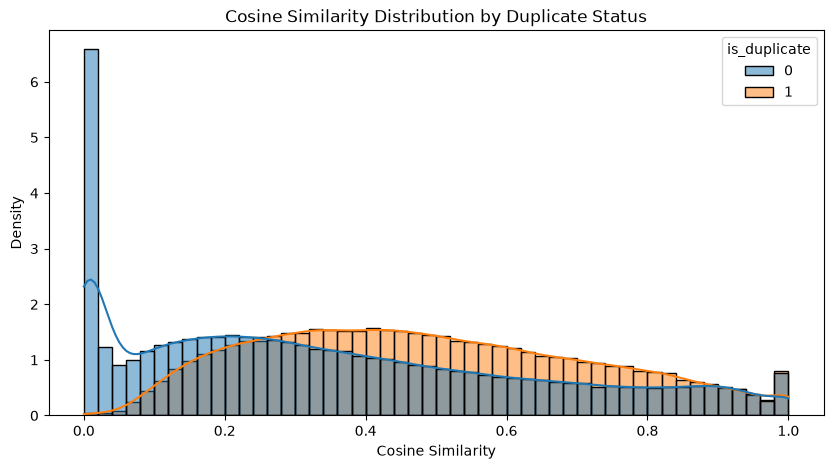

In [55]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="cosine_similarity",
    hue="is_duplicate",
    bins=50,
    kde=True,
    stat="density",
    common_norm=False
)

plt.title("Cosine Similarity Distribution by Duplicate Status")
plt.xlabel("Cosine Similarity")
plt.ylabel("Density")

plt.show()

### 5.8 High-Similarity Question Pairs

We inspect question pairs with very high TF-IDF cosine similarity.

This allows us to qualitatively evaluate whether high textual similarity corresponds to duplicate questions.

In [56]:
df.sort_values(
    "cosine_similarity",
    ascending=False
)[
    [
        "question1",
        "question2",
        "cosine_similarity",
        "is_duplicate"
    ]
].head(10)

,question1,question2,cosine_similarity,is_duplicate
256931,What was Deere & Co's IPO price? What would 10...,What was Monsanto Co's IPO price? What would 1...,1.0,0
328147,Is it true that Economic recession is going to...,Is it true that Economic recession is going to...,1.0,1
206725,Who would be a better life partner for you & W...,Who would be a better life partner for you? Wh...,1.0,1
132504,What do you mean by hi?,"What do you mean by ""hi""?",1.0,1
150364,"What does ""="" mean in java?",What does; .; mean in Java?,1.0,0
150724,What is the square root of 1?,What is the square root of 1-i?,1.0,0
152105,What is the meaning of 'eochapi' in Korean?,"What is the meaning of ""naega"" in Korean?",1.0,0
332088,How does the HP OfficeJet 4620 Airprint compar...,How does the HP OfficeJet 4620 Airprint compar...,1.0,0
328500,How do I survive a long distance relationship?,How do I survive long distance relationship?,1.0,1
153239,What is a suitable inpatient drug and alcohol ...,What is a suitable inpatient drug and alcohol ...,1.0,0


### 5.9 Low-Similarity Question Pairs

We inspect question pairs with low cosine similarity.

In [57]:
df.sort_values(
    "cosine_similarity",
    ascending=True
)[
    [
        "question1",
        "question2",
        "cosine_similarity",
        "is_duplicate"
    ]
].head(10)

,question1,question2,cosine_similarity,is_duplicate
63786,Organic Chemistry: What is the difference betw...,How do you find total number of isomers of alk...,0.0,0
321864,Can a WWDC 2011 ticket be used by different pe...,When did WWDC 2013 take place in September?,0.0,0
60,At what cost does so much privacy as in German...,Are there any people who genuinely enjoy salad...,0.0,0
246994,Am I doing Right? Please see details.?,Are there trekking options near Gangtok that c...,0.0,0
246999,Why are patent drawings signed by the attorney...,How can Polysporin be used on dogs?,0.0,0
128435,How are you so badass?,What is acetic acid medium?,0.0,0
52978,Career Advice: Which career is better - Charte...,How can I get a job at Korg?,0.0,0
221998,Whose death was the most embarrassing of all t...,Can I continue my light weight/heavy repetitio...,0.0,0
19,How much is 30 kV in HP?,Where can I find a conversion chart for CC to ...,0.0,0
344990,What are the reviews of SensoVision System?,Is Lothar Matthaus Germany's greatest footballer?,0.0,0


## Phase 6: Train/Test Split and Machine Learning Preparation

The dataset is now ready for Machine Learning.

Before training a model, the data must be divided into separate training and testing sets.

The training set is used to learn patterns from the question pairs, while the testing set is kept unseen and is used to evaluate how well the model performs on new data.

We use an 80:20 train-test split.

To avoid data leakage, the final TF-IDF vectorizer will be fitted only on the training questions and then used to transform both the training and testing questions.

The target variable is:

- `0` → Non-duplicate question pair
- `1` → Duplicate question pair

### 6.1 Selecting Features and Target

The target variable is `is_duplicate`.

The numerical features created during the feature engineering stage will be used as additional Machine Learning features.

The raw question text is kept separately because it will be processed using TF-IDF.

In [58]:
# Target variable
y = df["is_duplicate"]

# Handcrafted numerical features
feature_columns = [
    "q1_clean_word_count",
    "q2_clean_word_count",
    "word_count_diff",
    "q1_clean_char_length",
    "q2_clean_char_length",
    "char_length_diff",
    "common_word_count",
    "common_word_ratio",
    "word_overlap_ratio",
    "length_ratio"
]

X_numeric = df[feature_columns].copy()

print("Numerical feature shape:", X_numeric.shape)
print("Target shape:", y.shape)

Numerical feature shape: (345033, 10)
Target shape: (345033,)


### 6.2 Train-Test Split

The dataset is divided into:

- 80% training data
- 20% testing data

In [59]:
from sklearn.model_selection import train_test_split

# Split indices instead of splitting large matrices directly
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(train_idx))
print("Testing samples:", len(test_idx))

Training samples: 276026
Testing samples: 69007


### 6.3 Checking Class Distribution After Splitting

We verify that the duplicate/non-duplicate ratio is similar in both training and testing sets.

Stratified splitting should preserve the original class distribution.

In [60]:
print("Original class distribution:")
print(y.value_counts(normalize=True))

print("\nTraining class distribution:")
print(y.loc[train_idx].value_counts(normalize=True))

print("\nTesting class distribution:")
print(y.loc[test_idx].value_counts(normalize=True))

Original class distribution:
is_duplicate
0    0.605023
1    0.394977
Name: proportion, dtype: float64

Training class distribution:
is_duplicate
0    0.605023
1    0.394977
Name: proportion, dtype: float64

Testing class distribution:
is_duplicate
0    0.605026
1    0.394974
Name: proportion, dtype: float64


### 6.4 Preparing Question Text for TF-IDF

The cleaned questions are separated according to the training and testing indices.

The training questions will be used to learn the TF-IDF vocabulary.

The testing questions will only be transformed using the vocabulary learned from the training data.

In [61]:
q1_train = df.loc[train_idx, "question1_clean"]
q2_train = df.loc[train_idx, "question2_clean"]

q1_test = df.loc[test_idx, "question1_clean"]
q2_test = df.loc[test_idx, "question2_clean"]

y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

print("Q1 training:", len(q1_train))
print("Q2 training:", len(q2_train))

print("Q1 testing:", len(q1_test))
print("Q2 testing:", len(q2_test))

Q1 training: 276026
Q2 training: 276026
Q1 testing: 69007
Q2 testing: 69007


### 6.5 Creating the Final TF-IDF Vectorizer

A new TF-IDF vectorizer is created for the final Machine Learning pipeline.

Unlike the exploratory TF-IDF vectorizer used in Phase 5, this vectorizer will be fitted only on the training questions.

This prevents information from the test set from influencing the model's learned vocabulary and helps avoid data leakage.

In [62]:
from sklearn.feature_extraction.text import TfidfVectorizer

final_tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

print("Final TF-IDF vectorizer created successfully.")

Final TF-IDF vectorizer created successfully.


### 6.6 Fitting TF-IDF on Training Data

The TF-IDF vocabulary is learned using only the training questions.

Both Question 1 and Question 2 from the training set are included so that the model can learn a common vocabulary for both sides of each question pair.

The testing questions are not used during fitting.

In [63]:
# Combine ONLY training questions
train_questions = pd.concat(
    [q1_train, q2_train],
    axis=0
)

print("Training questions used for TF-IDF:", len(train_questions))

# Fit only on training data
final_tfidf.fit(train_questions)

print(
    "Final TF-IDF vocabulary size:",
    len(final_tfidf.vocabulary_)
)

Training questions used for TF-IDF: 552052
Final TF-IDF vocabulary size: 50000


### 6.7 Transforming Training and Testing Questions

The fitted TF-IDF vectorizer is used to transform Question 1 and Question 2 separately.

The vectorizer is not fitted again on the testing data.

This ensures that the testing data remains unseen during the learning process.

In [64]:
# Training TF-IDF
q1_train_tfidf = final_tfidf.transform(q1_train)
q2_train_tfidf = final_tfidf.transform(q2_train)

# Testing TF-IDF
q1_test_tfidf = final_tfidf.transform(q1_test)
q2_test_tfidf = final_tfidf.transform(q2_test)

print("Q1 train TF-IDF:", q1_train_tfidf.shape)
print("Q2 train TF-IDF:", q2_train_tfidf.shape)

print("Q1 test TF-IDF:", q1_test_tfidf.shape)
print("Q2 test TF-IDF:", q2_test_tfidf.shape)

Q1 train TF-IDF: (276026, 50000)
Q2 train TF-IDF: (276026, 50000)
Q1 test TF-IDF: (69007, 50000)
Q2 test TF-IDF: (69007, 50000)


### 6.8 Calculating Final TF-IDF Cosine Similarity

Cosine similarity is calculated separately for the training and testing question pairs.

Because the TF-IDF vectorizer was fitted only on the training data, these similarity features do not use information learned from the test set.

The resulting similarity score will be combined with the handcrafted numerical features.

In [65]:
# Training cosine similarity
train_cosine = q1_train_tfidf.multiply(
    q2_train_tfidf
).sum(axis=1)

train_cosine = np.asarray(
    train_cosine
).ravel()

# Testing cosine similarity
test_cosine = q1_test_tfidf.multiply(
    q2_test_tfidf
).sum(axis=1)

test_cosine = np.asarray(
    test_cosine
).ravel()

print("Training cosine similarity shape:", train_cosine.shape)
print("Testing cosine similarity shape:", test_cosine.shape)

Training cosine similarity shape: (276026,)
Testing cosine similarity shape: (69007,)


### 6.9 Combining Engineered Features with TF-IDF Similarity

The handcrafted numerical features are combined with cosine similarity.

This creates the final feature set for the first Machine Learning experiments.

The model will therefore receive information about:

- Question lengths
- Word overlap
- Common words
- Length ratios
- TF-IDF textual similarity

In [66]:
# Numerical features for train and test
X_train_numeric = df.loc[
    train_idx,
    feature_columns
].copy()

X_test_numeric = df.loc[
    test_idx,
    feature_columns
].copy()

# Add cosine similarity
X_train_numeric["cosine_similarity"] = train_cosine
X_test_numeric["cosine_similarity"] = test_cosine

print("Final training feature shape:", X_train_numeric.shape)
print("Final testing feature shape:", X_test_numeric.shape)

Final training feature shape: (276026, 11)
Final testing feature shape: (69007, 11)


### 6.10 Final Feature Quality Check

Before training the Machine Learning model, we check for missing (`NaN`) and infinite values.

Machine Learning algorithms generally require valid numerical values, so any problematic values must be identified before model training.

In [67]:
print("Missing values in training features:")
print(X_train_numeric.isnull().sum())

print("\nMissing values in testing features:")
print(X_test_numeric.isnull().sum())

print("\nInfinite values in training features:",
      np.isinf(X_train_numeric).sum().sum())

print("Infinite values in testing features:",
      np.isinf(X_test_numeric).sum().sum())

Missing values in training features:
q1_clean_word_count     0
q2_clean_word_count     0
word_count_diff         0
q1_clean_char_length    0
q2_clean_char_length    0
char_length_diff        0
common_word_count       0
common_word_ratio       0
word_overlap_ratio      0
length_ratio            0
cosine_similarity       0
dtype: int64

Missing values in testing features:
q1_clean_word_count     0
q2_clean_word_count     0
word_count_diff         0
q1_clean_char_length    0
q2_clean_char_length    0
char_length_diff        0
common_word_count       0
common_word_ratio       0
word_overlap_ratio      0
length_ratio            0
cosine_similarity       0
dtype: int64

Infinite values in training features: 0
Infinite values in testing features: 0


### 6.11 Feature Scaling

The numerical features have different scales.

For example, character-length differences can have much larger values than similarity ratios.

StandardScaler is used to place the numerical features on a comparable scale.

Scaling is particularly useful for distance-based and linear Machine Learning algorithms such as Logistic Regression.

In [68]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_numeric
)

X_test_scaled = scaler.transform(
    X_test_numeric
)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (276026, 11)
Scaled testing shape: (69007, 11)


## Phase 7: Machine Learning Model Training and Model Selection

The feature engineering and data preparation stages are now complete.

In this phase, multiple Machine Learning algorithms will be trained and compared to determine which model performs best for duplicate question detection.

The following models will be evaluated:

1. Logistic Regression
2. Linear Support Vector Machine
3. Random Forest
4. Gradient Boosting

Logistic Regression and Linear SVM are suitable baseline models for classification using numerical and NLP-derived features.

Random Forest and Gradient Boosting are tree-based Machine Learning algorithms that can capture nonlinear relationships between engineered features.

GridSearchCV will be used to tune the hyperparameters of selected models.

The final model will be selected using evaluation metrics such as F1-score and ROC-AUC rather than accuracy alone.

### 7.1 Import Required Libraries

In [69]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("All Machine Learning libraries imported successfully.")

All Machine Learning libraries imported successfully.


### 7.2 Verifying the Training and Testing Data

Before model training, we verify the dimensions of the feature matrices and target variables.

The training and testing datasets must contain the same number of features.

In [70]:
print("X_train shape:", X_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (276026, 11)
X_test shape: (69007, 11)
y_train shape: (276026,)
y_test shape: (69007,)


### 7.3 Logistic Regression Baseline

Logistic Regression is used as the baseline Machine Learning model.

It is a linear classification algorithm that estimates the probability that a question pair belongs to the duplicate class.

The model is computationally efficient and provides a useful baseline against which more complex algorithms can be compared.

In [71]:
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression training completed.")

Logistic Regression training completed.


### 7.4 Evaluate Logistic Regression

In [72]:
y_pred_lr = logistic_model.predict(X_test_scaled)

y_prob_lr = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

print("Logistic Regression Results")
print("-" * 40)

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_lr)
)

print(
    "Precision:",
    precision_score(y_test, y_pred_lr)
)

print(
    "Recall:",
    recall_score(y_test, y_pred_lr)
)

print(
    "F1 Score:",
    f1_score(y_test, y_pred_lr)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_lr)
)

Logistic Regression Results
----------------------------------------
Accuracy: 0.6420797890069123
Precision: 0.5324105762161888
Recall: 0.7705459348400352
F1 Score: 0.6297168043416338
ROC-AUC: 0.7149096197889542


### 7.5 Linear Support Vector Machine

Linear Support Vector Machine (SVM) is a powerful classification algorithm that attempts to find a decision boundary that separates duplicate and non-duplicate question pairs.

SVM is commonly effective for text-related Machine Learning problems because it can work well with numerical representations derived from NLP.

In [73]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42,
    max_iter=5000
)

svm_model.fit(
    X_train_scaled,
    y_train
)

print("Linear SVM training completed.")

Linear SVM training completed.


In [74]:
y_pred_svm = svm_model.predict(X_test_scaled)

svm_scores = svm_model.decision_function(X_test_scaled)

print("Linear SVM Results")
print("-" * 40)

print("Accuracy:",
      accuracy_score(y_test, y_pred_svm))

print("Precision:",
      precision_score(y_test, y_pred_svm))

print("Recall:",
      recall_score(y_test, y_pred_svm))

print("F1 Score:",
      f1_score(y_test, y_pred_svm))

print("ROC-AUC:",
      roc_auc_score(y_test, svm_scores))

Linear SVM Results
----------------------------------------
Accuracy: 0.6414421725332212
Precision: 0.5314510275086981
Recall: 0.7789844437921926
F1 Score: 0.6318389453479548
ROC-AUC: 0.7158631590066754


In [75]:
print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=[
            "Non-Duplicate",
            "Duplicate"
        ]
    )
)

               precision    recall  f1-score   support

Non-Duplicate       0.79      0.55      0.65     41751
    Duplicate       0.53      0.78      0.63     27256

     accuracy                           0.64     69007
    macro avg       0.66      0.67      0.64     69007
 weighted avg       0.69      0.64      0.64     69007



### 7.6 Random Forest Classifier

Random Forest is an ensemble Machine Learning algorithm that combines multiple decision trees.

Unlike Logistic Regression and Linear SVM, Random Forest can learn nonlinear relationships between the engineered features.

The model uses the 12 engineered numerical features, including TF-IDF cosine similarity.

In [76]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_numeric,
    y_train
)

print("Random Forest training completed.")

Random Forest training completed.


In [77]:
y_pred_rf = rf_model.predict(X_test_numeric)

y_prob_rf = rf_model.predict_proba(
    X_test_numeric
)[:, 1]

print("Random Forest Results")
print("-" * 40)

print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("Precision:",
      precision_score(y_test, y_pred_rf))

print("Recall:",
      recall_score(y_test, y_pred_rf))

print("F1 Score:",
      f1_score(y_test, y_pred_rf))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_rf))

Random Forest Results
----------------------------------------
Accuracy: 0.6759604098134971
Precision: 0.5590114526823388
Recall: 0.8506383915468154
F1 Score: 0.6746591785366137
ROC-AUC: 0.7760855125791293


### 7.7 Gradient Boosting Classifier

Gradient Boosting is an ensemble Machine Learning algorithm that builds decision trees sequentially.

Each new tree attempts to correct errors made by the previous trees.

This allows the model to capture nonlinear relationships between the engineered features and the duplicate-question target.

In [78]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(
    X_train_numeric,
    y_train
)

print("Gradient Boosting training completed.")

Gradient Boosting training completed.


In [79]:
y_pred_gb = gb_model.predict(
    X_test_numeric
)

y_prob_gb = gb_model.predict_proba(
    X_test_numeric
)[:, 1]

print("Gradient Boosting Results")
print("-" * 40)

print("Accuracy:",
      accuracy_score(y_test, y_pred_gb))

print("Precision:",
      precision_score(y_test, y_pred_gb))

print("Recall:",
      recall_score(y_test, y_pred_gb))

print("F1 Score:",
      f1_score(y_test, y_pred_gb))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_gb))

Gradient Boosting Results
----------------------------------------
Accuracy: 0.6823220832669149
Precision: 0.5883054102377326
Recall: 0.6518931611388318
F1 Score: 0.6184691426781301
ROC-AUC: 0.759657614713678


### 7.8 compare all four models

In [80]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],

    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb)
    ],

    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb)
    ],

    "F1": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, svm_scores),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_gb)
    ]
})

results.sort_values(
    "F1",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,Random Forest,0.675960,0.559011,0.850638,0.674659,0.776086
1,Linear SVM,0.641442,0.531451,0.778984,0.631839,0.715863
0,Logistic Regression,0.642080,0.532411,0.770546,0.629717,0.714910
3,Gradient Boosting,0.682322,0.588305,0.651893,0.618469,0.759658


### 7.9 Random Forest Hyperparameter Tuning Using GridSearchCV

Random Forest produced the strongest baseline performance among the evaluated models.

Therefore, GridSearchCV is used to search for a better combination of Random Forest hyperparameters.

The parameters considered include:

- `n_estimators`: Number of decision trees.
- `max_depth`: Maximum depth of each tree.
- `min_samples_leaf`: Minimum number of samples required at a leaf node.

Three-fold cross-validation is used during GridSearchCV.

The F1-score is selected as the optimization metric because duplicate question detection requires a balance between precision and recall.

The test dataset remains completely unseen during hyperparameter tuning.

In [81]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 15, 20],
    "min_samples_leaf": [2, 5]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    param_grid=rf_param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=2
)

print("Starting Random Forest GridSearchCV...")

rf_grid.fit(
    X_train_numeric,
    y_train
)

print("\nGridSearchCV completed.")

print("\nBest Parameters:")
print(rf_grid.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(rf_grid.best_score_)

Starting Random Forest GridSearchCV...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

GridSearchCV completed.

Best Parameters:
{'max_depth': 15, 'min_samples_leaf': 5, 'n_estimators': 200}

Best Cross-Validation F1 Score:
0.6766580450406098


### 7.10 Evaluation of the Tuned Random Forest

The best Random Forest identified by GridSearchCV is evaluated on the unseen testing dataset.

The test set was not used during hyperparameter optimization, so this provides an unbiased estimate of the tuned model's performance.

In [82]:
best_rf = rf_grid.best_estimator_

# Predictions
y_pred_rf_tuned = best_rf.predict(
    X_test_numeric
)

# Probability for positive class
y_prob_rf_tuned = best_rf.predict_proba(
    X_test_numeric
)[:, 1]

print("Tuned Random Forest Results")
print("-" * 45)

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_rf_tuned)
)

print(
    "Precision:",
    precision_score(y_test, y_pred_rf_tuned)
)

print(
    "Recall:",
    recall_score(y_test, y_pred_rf_tuned)
)

print(
    "F1 Score:",
    f1_score(y_test, y_pred_rf_tuned)
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        y_prob_rf_tuned
    )
)

Tuned Random Forest Results
---------------------------------------------
Accuracy: 0.6759604098134971
Precision: 0.5590114526823388
Recall: 0.8506383915468154
F1 Score: 0.6746591785366137
ROC-AUC: 0.7760855125791293


In [83]:
print(
    classification_report(
        y_test,
        y_pred_rf_tuned,
        target_names=[
            "Non-Duplicate",
            "Duplicate"
        ]
    )
)

               precision    recall  f1-score   support

Non-Duplicate       0.85      0.56      0.68     41751
    Duplicate       0.56      0.85      0.67     27256

     accuracy                           0.68     69007
    macro avg       0.71      0.71      0.68     69007
 weighted avg       0.74      0.68      0.68     69007



### 7.11 Confusion Matrix of the Tuned Random Forest

The confusion matrix shows the number of:

- True Negatives
- False Positives
- False Negatives
- True Positives

It helps us understand the types of errors made by the duplicate question detection model.

In [84]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf_tuned
)

print("Confusion Matrix:")
print(cm_rf)

Confusion Matrix:
[[23461 18290]
 [ 4071 23185]]


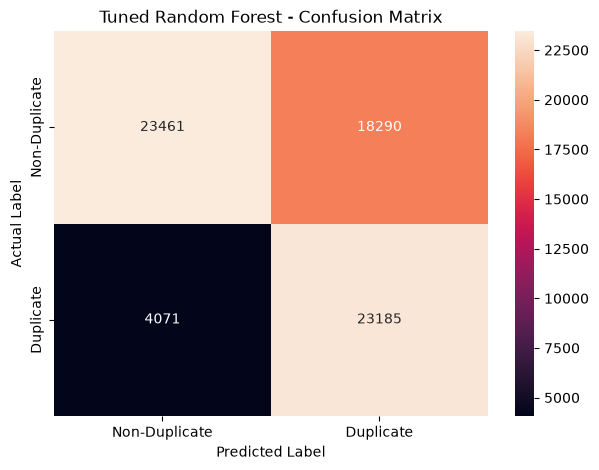

In [85]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=[
        "Non-Duplicate",
        "Duplicate"
    ],
    yticklabels=[
        "Non-Duplicate",
        "Duplicate"
    ]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Tuned Random Forest - Confusion Matrix")

plt.show()

### 7.12 Random Forest Before and After Hyperparameter Tuning

The performance of the baseline Random Forest is compared with the optimized Random Forest obtained using GridSearchCV.

This comparison shows whether hyperparameter optimization improved the model's generalization performance.

In [86]:
rf_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Baseline Random Forest": [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf),
        roc_auc_score(y_test, y_prob_rf)
    ],

    "Tuned Random Forest": [
        accuracy_score(y_test, y_pred_rf_tuned),
        precision_score(y_test, y_pred_rf_tuned),
        recall_score(y_test, y_pred_rf_tuned),
        f1_score(y_test, y_pred_rf_tuned),
        roc_auc_score(y_test, y_prob_rf_tuned)
    ]
})

rf_comparison

,Metric,Baseline Random Forest,Tuned Random Forest
0,Accuracy,0.675960,0.675960
1,Precision,0.559011,0.559011
2,Recall,0.850638,0.850638
3,F1 Score,0.674659,0.674659
4,ROC-AUC,0.776086,0.776086


### 7.13 Random Forest Feature Importance

Random Forest provides feature importance scores that indicate how useful each engineered feature was for making predictions.

This helps us understand which characteristics of question pairs are most useful for identifying duplicate questions.

In [87]:
feature_importance = pd.DataFrame({
    "Feature": X_train_numeric.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
7,common_word_ratio,0.275410
10,cosine_similarity,0.188497
8,word_overlap_ratio,0.174753
6,common_word_count,0.080134
3,q1_clean_char_length,0.051188
5,char_length_diff,0.049166
9,length_ratio,0.044165
4,q2_clean_char_length,0.043613
1,q2_clean_word_count,0.034745
2,word_count_diff,0.032860


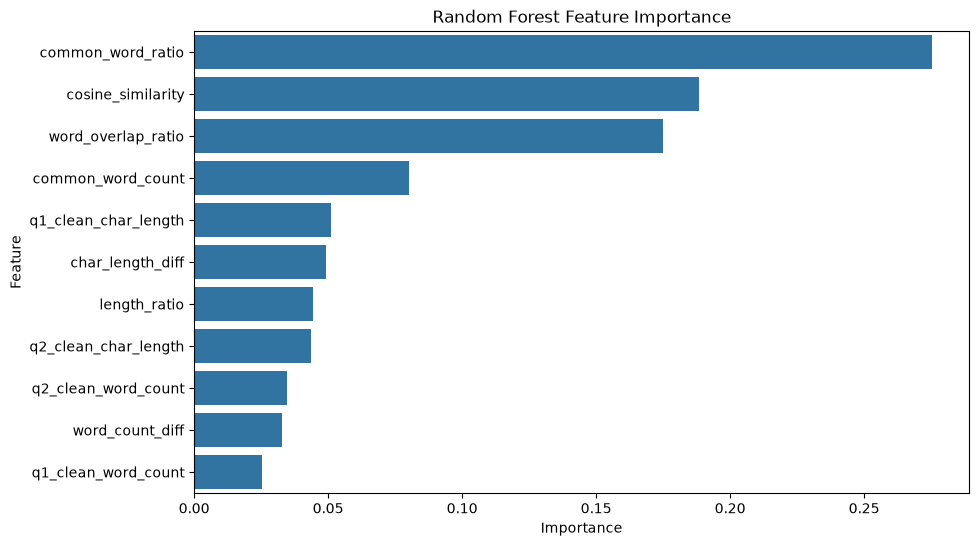

In [88]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

# Phase 8: Advanced TF-IDF-Based Machine Learning

The previous models used engineered numerical features and cosine similarity.

Although cosine similarity is useful for measuring the similarity between two questions, reducing the complete TF-IDF representation to a single similarity score results in loss of textual information.

Therefore, in this phase, we preserve more information from the TF-IDF representations.

For each question pair, two types of pairwise TF-IDF features are created:

1. Absolute difference between the TF-IDF vectors.
2. Element-wise product between the TF-IDF vectors.

These features capture both differences and common textual patterns between the two questions.

A Linear Support Vector Machine is then trained on these sparse features.

This approach uses classical Machine Learning and NLP and does not use Deep Learning.

In [90]:
from scipy.sparse import hstack

# Absolute difference between Q1 and Q2
train_diff = abs(
    q1_train_tfidf - q2_train_tfidf
)

test_diff = abs(
    q1_test_tfidf - q2_test_tfidf
)

# Element-wise multiplication
train_product = q1_train_tfidf.multiply(
    q2_train_tfidf
)

test_product = q1_test_tfidf.multiply(
    q2_test_tfidf
)

print("Difference matrix:", train_diff.shape)
print("Product matrix:", train_product.shape)

Difference matrix: (276026, 50000)
Product matrix: (276026, 50000)


In [91]:
X_train_tfidf_pair = hstack([
    train_diff,
    train_product
]).tocsr()

X_test_tfidf_pair = hstack([
    test_diff,
    test_product
]).tocsr()

print(
    "Training shape:",
    X_train_tfidf_pair.shape
)

print(
    "Testing shape:",
    X_test_tfidf_pair.shape
)

Training shape: (276026, 100000)
Testing shape: (69007, 100000)


## 8.1 Linear SVM with TF-IDF Pair Features

Linear Support Vector Machine is suitable for high-dimensional sparse text data.

Unlike Random Forest, which was trained on a small number of engineered numerical features, Linear SVM can directly learn from the large sparse TF-IDF representation.

The model is trained using the pairwise difference and product features generated from the two questions.

In [94]:
from sklearn.svm import LinearSVC

tfidf_svm = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=42,
    max_iter=5000
)

print("Training TF-IDF Linear SVM...")

tfidf_svm.fit(
    X_train_tfidf_pair,
    y_train
)

print("Training completed.")

Training TF-IDF Linear SVM...
Training completed.


In [95]:
y_pred_tfidf_svm = tfidf_svm.predict(
    X_test_tfidf_pair
)

tfidf_svm_scores = tfidf_svm.decision_function(
    X_test_tfidf_pair
)

print("TF-IDF Linear SVM Results")
print("-" * 45)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred_tfidf_svm
    )
)

print(
    "Precision:",
    precision_score(
        y_test,
        y_pred_tfidf_svm
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        y_pred_tfidf_svm
    )
)

print(
    "F1 Score:",
    f1_score(
        y_test,
        y_pred_tfidf_svm
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        tfidf_svm_scores
    )
)

TF-IDF Linear SVM Results
---------------------------------------------
Accuracy: 0.8074108423783094
Precision: 0.7266619059984419
Recall: 0.8213604343997651
F1 Score: 0.7711146321300634
ROC-AUC: 0.891038814808947


### 8.2 TF-IDF + Linear SVM Results

The TF-IDF-based Linear SVM model significantly outperformed the previously evaluated Machine Learning models.

In [96]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_tfidf_svm,
        target_names=[
            "Non-Duplicate",
            "Duplicate"
        ]
    )
)

               precision    recall  f1-score   support

Non-Duplicate       0.87      0.80      0.83     41751
    Duplicate       0.73      0.82      0.77     27256

     accuracy                           0.81     69007
    macro avg       0.80      0.81      0.80     69007
 weighted avg       0.81      0.81      0.81     69007



### 8.3 Confusion Matrix

The confusion matrix is used to analyze the classification errors made by the TF-IDF Linear SVM model.

It shows:

- True Negatives: Correctly identified non-duplicate questions.
- False Positives: Non-duplicate questions incorrectly classified as duplicates.
- False Negatives: Duplicate questions incorrectly classified as non-duplicates.
- True Positives: Correctly identified duplicate questions.

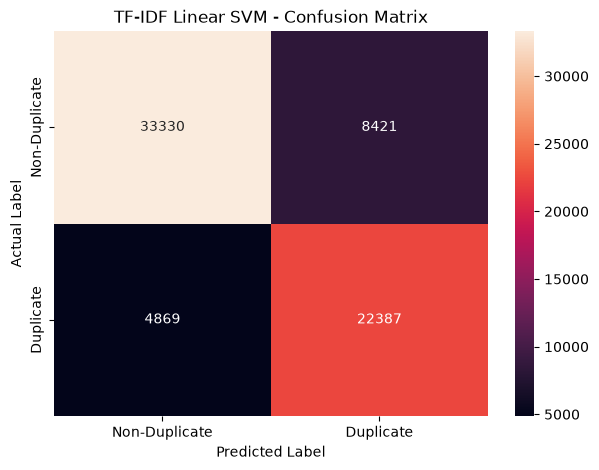

In [97]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_tfidf_svm
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "Non-Duplicate",
        "Duplicate"
    ],
    yticklabels=[
        "Non-Duplicate",
        "Duplicate"
    ]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("TF-IDF Linear SVM - Confusion Matrix")

plt.show()

### 8.4 ROC Curve

The ROC curve evaluates the ability of the classifier to distinguish between duplicate and non-duplicate question pairs across different classification thresholds.

The Area Under the ROC Curve (ROC-AUC) summarizes this performance.

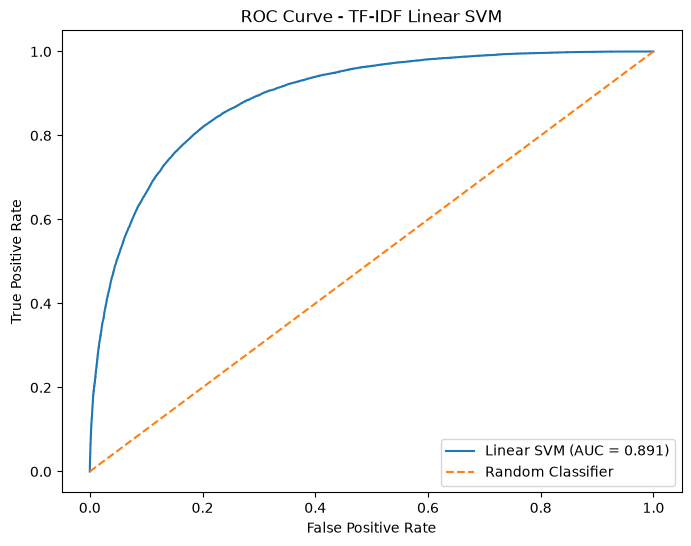

In [98]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(
    y_test,
    tfidf_svm_scores
)

auc_score = roc_auc_score(
    y_test,
    tfidf_svm_scores
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Linear SVM (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - TF-IDF Linear SVM")
plt.legend()

plt.show()

### 8.5 Hyperparameter Tuning of Linear SVM

The Linear SVM achieved the strongest performance among the evaluated models.

GridSearchCV is therefore used to determine whether changing the regularization parameter `C` can improve the model.

The F1-score is used as the optimization metric because duplicate-question detection requires a balance between precision and recall.

In [99]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC

svm_param_grid = {
    "C": [0.1, 0.5, 1.0, 2.0]
}

svm_grid = GridSearchCV(
    estimator=LinearSVC(
        class_weight="balanced",
        random_state=42,
        max_iter=5000
    ),
    param_grid=svm_param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=2
)

print("Starting Linear SVM GridSearchCV...")

svm_grid.fit(
    X_train_tfidf_pair,
    y_train
)

print("\nGridSearchCV completed.")

print("\nBest Parameters:")
print(svm_grid.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(svm_grid.best_score_)

Starting Linear SVM GridSearchCV...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

GridSearchCV completed.

Best Parameters:
{'C': 0.5}

Best Cross-Validation F1 Score:
0.7608572487146592


In [100]:
best_svm = svm_grid.best_estimator_

y_pred_svm_tuned = best_svm.predict(
    X_test_tfidf_pair
)

svm_tuned_scores = best_svm.decision_function(
    X_test_tfidf_pair
)

print("Tuned TF-IDF Linear SVM Results")
print("-" * 50)

print("Accuracy:",
      accuracy_score(y_test, y_pred_svm_tuned))

print("Precision:",
      precision_score(y_test, y_pred_svm_tuned))

print("Recall:",
      recall_score(y_test, y_pred_svm_tuned))

print("F1 Score:",
      f1_score(y_test, y_pred_svm_tuned))

print("ROC-AUC:",
      roc_auc_score(y_test, svm_tuned_scores))

Tuned TF-IDF Linear SVM Results
--------------------------------------------------
Accuracy: 0.8059617140290115
Precision: 0.7227255204317656
Recall: 0.8253962430290578
F1 Score: 0.7706563442038915
ROC-AUC: 0.8928386237127788


# Phase 9: Final Model Selection

Several classical Machine Learning models were trained and evaluated for duplicate question detection.

The evaluated models included:

1. Logistic Regression
2. Linear SVM
3. Random Forest
4. Gradient Boosting
5. TF-IDF Pair Features + Linear SVM
6. Tuned TF-IDF Pair Features + Linear SVM

The TF-IDF-based Linear SVM significantly outperformed the models trained only on engineered numerical features.

GridSearchCV was then applied to the Linear SVM to optimize the regularization parameter C.

The best value of C was found to be 0.5.

The final tuned model achieved approximately 80.60% accuracy and 89.28% ROC-AUC on the unseen test dataset.

Therefore, the tuned TF-IDF Linear SVM was selected as the final Machine Learning model for deployment.

### 9.1 — Final Model Comparison

In [101]:
import pandas as pd

final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM",
        "Random Forest",
        "Gradient Boosting",
        "TF-IDF + Linear SVM",
        "Tuned TF-IDF + Linear SVM"
    ],
    
    "Accuracy": [
        0.642080,
        0.641442,
        0.675960,
        0.682322,
        0.807411,
        0.805962
    ],
    
    "Precision": [
        0.532411,
        0.531451,
        0.559011,
        0.588305,
        0.726662,
        0.722726
    ],
    
    "Recall": [
        0.770546,
        0.778984,
        0.850638,
        0.651893,
        0.821360,
        0.825396
    ],
    
    "F1": [
        0.629717,
        0.631839,
        0.674659,
        0.618469,
        0.771115,
        0.770656
    ],
    
    "ROC-AUC": [
        0.714910,
        0.715863,
        0.776086,
        0.759658,
        0.891039,
        0.892839
    ]
})

final_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.642080,0.532411,0.770546,0.629717,0.714910
1,Linear SVM,0.641442,0.531451,0.778984,0.631839,0.715863
2,Random Forest,0.675960,0.559011,0.850638,0.674659,0.776086
3,Gradient Boosting,0.682322,0.588305,0.651893,0.618469,0.759658
4,TF-IDF + Linear SVM,0.807411,0.726662,0.821360,0.771115,0.891039
5,Tuned TF-IDF + Linear SVM,0.805962,0.722726,0.825396,0.770656,0.892839


### 9.2 — Visualize Model Comparison

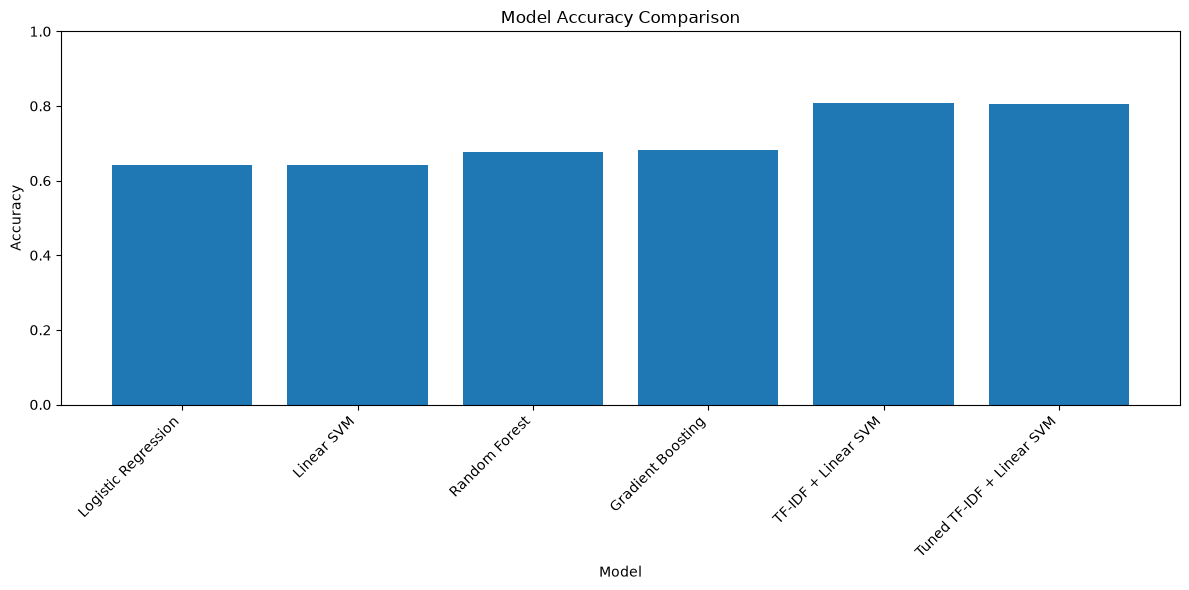

In [102]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    final_results["Model"],
    final_results["Accuracy"]
)

plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Model Accuracy Comparison")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.ylim(0, 1)

plt.tight_layout()
plt.show()

### 9.3 — Final Classification Report

In [103]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_svm_tuned,
        target_names=[
            "Non-Duplicate",
            "Duplicate"
        ]
    )
)

               precision    recall  f1-score   support

Non-Duplicate       0.87      0.79      0.83     41751
    Duplicate       0.72      0.83      0.77     27256

     accuracy                           0.81     69007
    macro avg       0.80      0.81      0.80     69007
 weighted avg       0.81      0.81      0.81     69007



### 9.4 — Final Confusion Matrix

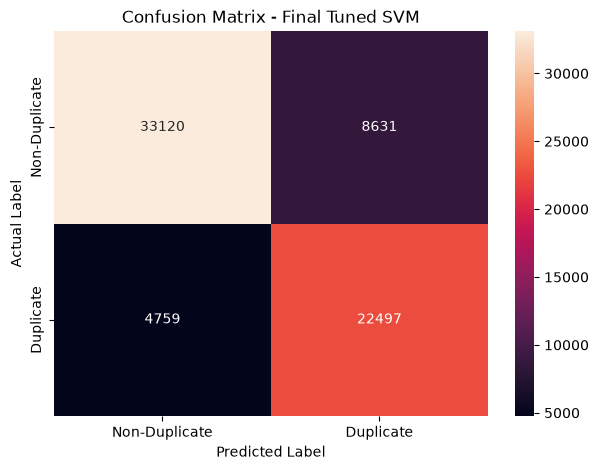

In [104]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_svm_tuned
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "Non-Duplicate",
        "Duplicate"
    ],
    yticklabels=[
        "Non-Duplicate",
        "Duplicate"
    ]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Final Tuned SVM")

plt.show()

# Phase 10: Model Saving and Deployment Preparation

In this phase, the final trained Machine Learning model and the fitted TF-IDF vectorizer are saved to disk.

Saving these objects allows us to reuse the trained model without training it again.

The saved files will later be loaded into a Streamlit application to perform duplicate-question prediction on new question pairs.

In [107]:
import pickle
import os

In [108]:
print("Final model:")
print(best_svm)

print("\nBest parameters:")
print(svm_grid.best_params_)

Final model:
LinearSVC(C=0.5, class_weight='balanced', max_iter=5000, random_state=42)

Best parameters:
{'C': 0.5}


In [109]:
with open("duplicate_question_svm.pkl", "wb") as file:
    pickle.dump(best_svm, file)

print("Final SVM model saved successfully.")

Final SVM model saved successfully.


In [110]:
print(
    "File exists:",
    os.path.exists("duplicate_question_svm.pkl")
)

File exists: True


In [111]:
with open("tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf, file)

print("TF-IDF vectorizer saved successfully.")

TF-IDF vectorizer saved successfully.


In [112]:
print("SVM model exists:",
      os.path.exists("duplicate_question_svm.pkl"))

print("TF-IDF vectorizer exists:",
      os.path.exists("tfidf_vectorizer.pkl"))

SVM model exists: True
TF-IDF vectorizer exists: True


In [113]:
model_size = os.path.getsize(
    "duplicate_question_svm.pkl"
)

vectorizer_size = os.path.getsize(
    "tfidf_vectorizer.pkl"
)

print(
    f"SVM model size: {model_size / (1024**2):.2f} MB"
)

print(
    f"TF-IDF vectorizer size: {vectorizer_size / (1024**2):.2f} MB"
)

SVM model size: 0.76 MB
TF-IDF vectorizer size: 1.88 MB


In [114]:
with open("duplicate_question_svm.pkl", "rb") as file:
    loaded_model = pickle.load(file)

with open("tfidf_vectorizer.pkl", "rb") as file:
    loaded_tfidf = pickle.load(file)

print("Model loaded successfully.")
print("Vectorizer loaded successfully.")

Model loaded successfully.
Vectorizer loaded successfully.


In [115]:
print(
    "Vocabulary size:",
    len(loaded_tfidf.vocabulary_)
)

Vocabulary size: 50000


In [116]:
question1 = "How can I learn Python programming?"

question2 = "What is the best way to learn Python?"

In [117]:
q1_clean = clean_text(question1)
q2_clean = clean_text(question2)

print("Question 1:")
print(q1_clean)

print("\nQuestion 2:")
print(q2_clean)

Question 1:
how can i learn python programming

Question 2:
what is the best way to learn python


In [118]:
q1_vector = loaded_tfidf.transform(
    [q1_clean]
)

q2_vector = loaded_tfidf.transform(
    [q2_clean]
)

print("Q1 shape:", q1_vector.shape)
print("Q2 shape:", q2_vector.shape)

Q1 shape: (1, 50000)
Q2 shape: (1, 50000)


In [119]:
q_diff = abs(
    q1_vector - q2_vector
)

q_product = q1_vector.multiply(
    q2_vector
)

In [120]:
q_pair_features = hstack([
    q_diff,
    q_product
]).tocsr()

print(
    "Pair feature shape:",
    q_pair_features.shape
)

Pair feature shape: (1, 100000)


In [121]:
prediction = loaded_model.predict(
    q_pair_features
)

print("Prediction:", prediction[0])

Prediction: 1


In [122]:
decision_score = loaded_model.decision_function(
    q_pair_features
)

print("Decision score:", decision_score[0])

Decision score: 0.05873692255069124


In [123]:
def predict_duplicate(question1, question2):

    # Clean text
    q1_clean = clean_text(question1)
    q2_clean = clean_text(question2)

    # TF-IDF transformation
    q1_vector = loaded_tfidf.transform(
        [q1_clean]
    )

    q2_vector = loaded_tfidf.transform(
        [q2_clean]
    )

    # Pair features
    q_diff = abs(
        q1_vector - q2_vector
    )

    q_product = q1_vector.multiply(
        q2_vector
    )

    q_pair_features = hstack([
        q_diff,
        q_product
    ]).tocsr()

    # Prediction
    prediction = loaded_model.predict(
        q_pair_features
    )[0]

    # Decision score
    score = loaded_model.decision_function(
        q_pair_features
    )[0]

    if prediction == 1:
        result = "Duplicate Question"
    else:
        result = "Non-Duplicate Question"

    return result, score

In [124]:
result, score = predict_duplicate(
    "How can I learn Python programming?",
    "What is the best way to learn Python?"
)

print("Result:", result)
print("Score:", score)

Result: Duplicate Question
Score: 0.05873692255069124


## Phase 10 Summary

In this phase, the final Machine Learning model and TF-IDF vectorizer were prepared for deployment.

The following tasks were completed:

- Saved the tuned Linear SVM model.
- Saved the fitted TF-IDF vectorizer.
- Verified that both files were successfully created.
- Loaded the saved model and vectorizer.
- Verified the 50,000-word TF-IDF vocabulary.
- Tested the complete prediction pipeline on new questions.
- Generated the required 100,000-dimensional TF-IDF pair representation.
- Successfully generated duplicate-question predictions.
- Created a reusable prediction function for deployment.

The saved model and vectorizer can now be integrated into a web application.

In the next phase, these components will be used to develop a Streamlit-based Duplicate Question Detection application where users can enter two questions and receive a prediction in real time.

# Phase 11: Streamlit Web Application

In this phase, the trained Duplicate Question Detection model is deployed as an interactive web application using Streamlit.

The application allows users to enter two questions and determine whether they are likely to have the same meaning.

The application uses the trained and saved:

- TF-IDF Vectorizer
- TF-IDF pair feature representation
- Linear SVM classifier

The prediction pipeline is the same as the pipeline used during model training.

# Phase 12: Requirements File

A `requirements.txt` file was created to list the Python libraries required to run the Duplicate Question Detection application.

The file makes the project easier to reproduce on another system because all required dependencies can be installed using a single command.